# 07 — Service Rating Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/cleaned_with_sentiment.csv')
print("Rating dist:")
print(df['Service Rating'].value_counts().sort_index())


Rating dist:
Service Rating
1    15267
2    30552
3     7704
4     7789
5    38688
Name: count, dtype: int64


## Features & Split

In [2]:
le = LabelEncoder()
df['Platform_E']  = le.fit_transform(df['Platform'])
df['Category_E']  = le.fit_transform(df['Product Category'])
df['Sentiment_E'] = le.fit_transform(df['Sentiment'].fillna('Neutral'))

tier_map = {'Express':0, 'On-Time':1, 'Slow':2, 'Very Late':3}
df['Tier_E'] = df['Delivery_Tier'].map(tier_map)

FEATURES = ['Delivery Time (Minutes)', 'Delay_Flag',
            'Order Value (INR)', 'Platform_E', 'Category_E',
            'Tier_E', 'Hour']

X = df[FEATURES]
y = df['Service Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_tr_s = sc.fit_transform(X_train)
X_te_s = sc.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (80000, 7)  Test: (20000, 7)


## Three Regression Models

In [3]:
def reg_eval(name, y_true, y_pred):
    y_clip = np.clip(y_pred, 1, 5)
    return {
        'Model': name,
        'RMSE' : round(np.sqrt(mean_squared_error(y_true, y_clip)), 4),
        'MAE'  : round(mean_absolute_error(y_true, y_clip),         4),
        'R2'   : round(r2_score(y_true, y_clip),                    4)
    }

# 1. Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_s, y_train)
ridge_res = reg_eval('Ridge', y_test, ridge.predict(X_te_s))

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=12,
                            min_samples_leaf=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_res  = reg_eval('Random Forest', y_test, rf_pred)

# 3. XGBoost / GBM
if HAS_XGB:
    m3 = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8,
                       random_state=42, verbosity=0)
    m3_name = 'XGBoost'
else:
    m3 = GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                    learning_rate=0.05, subsample=0.8, random_state=42)
    m3_name = 'Gradient Boosting'

m3.fit(X_train, y_train)
m3_pred = m3.predict(X_test)
m3_res  = reg_eval(m3_name, y_test, m3_pred)

results = pd.DataFrame([ridge_res, rf_res, m3_res]).set_index('Model')
print(results)
print("\nBest (lowest RMSE):", results['RMSE'].idxmin())


                     RMSE     MAE      R2
Model                                    
Ridge              1.5803  1.4841 -0.0001
Random Forest      1.5824  1.4850 -0.0029
Gradient Boosting  1.5828  1.4850 -0.0034

Best (lowest RMSE): Ridge


**Honest read of these numbers:** R² is close to 0 (even slightly negative for the tree
models, meaning they perform marginally worse than just predicting the mean rating every
time). I checked the direct correlation between each feature and `Service Rating` before
concluding this — delivery time, delay, order value all sit under 0.003 correlation. Ratings
in this dataset are not explained by the operational variables collected.

This is a legitimate and reportable finding, not a failed model. In a real-world dataset,
I would expect delivery time and delay status to meaningfully predict rating — that's the
entire premise tested in Notebook 03's hypothesis test. The honest conclusion here is that
**this particular sample's `Service Rating` and `Refund Requested` columns appear to be
generated independently of the operational columns**, which is worth stating directly in
interviews rather than presenting an inflated R².

## Visualisation

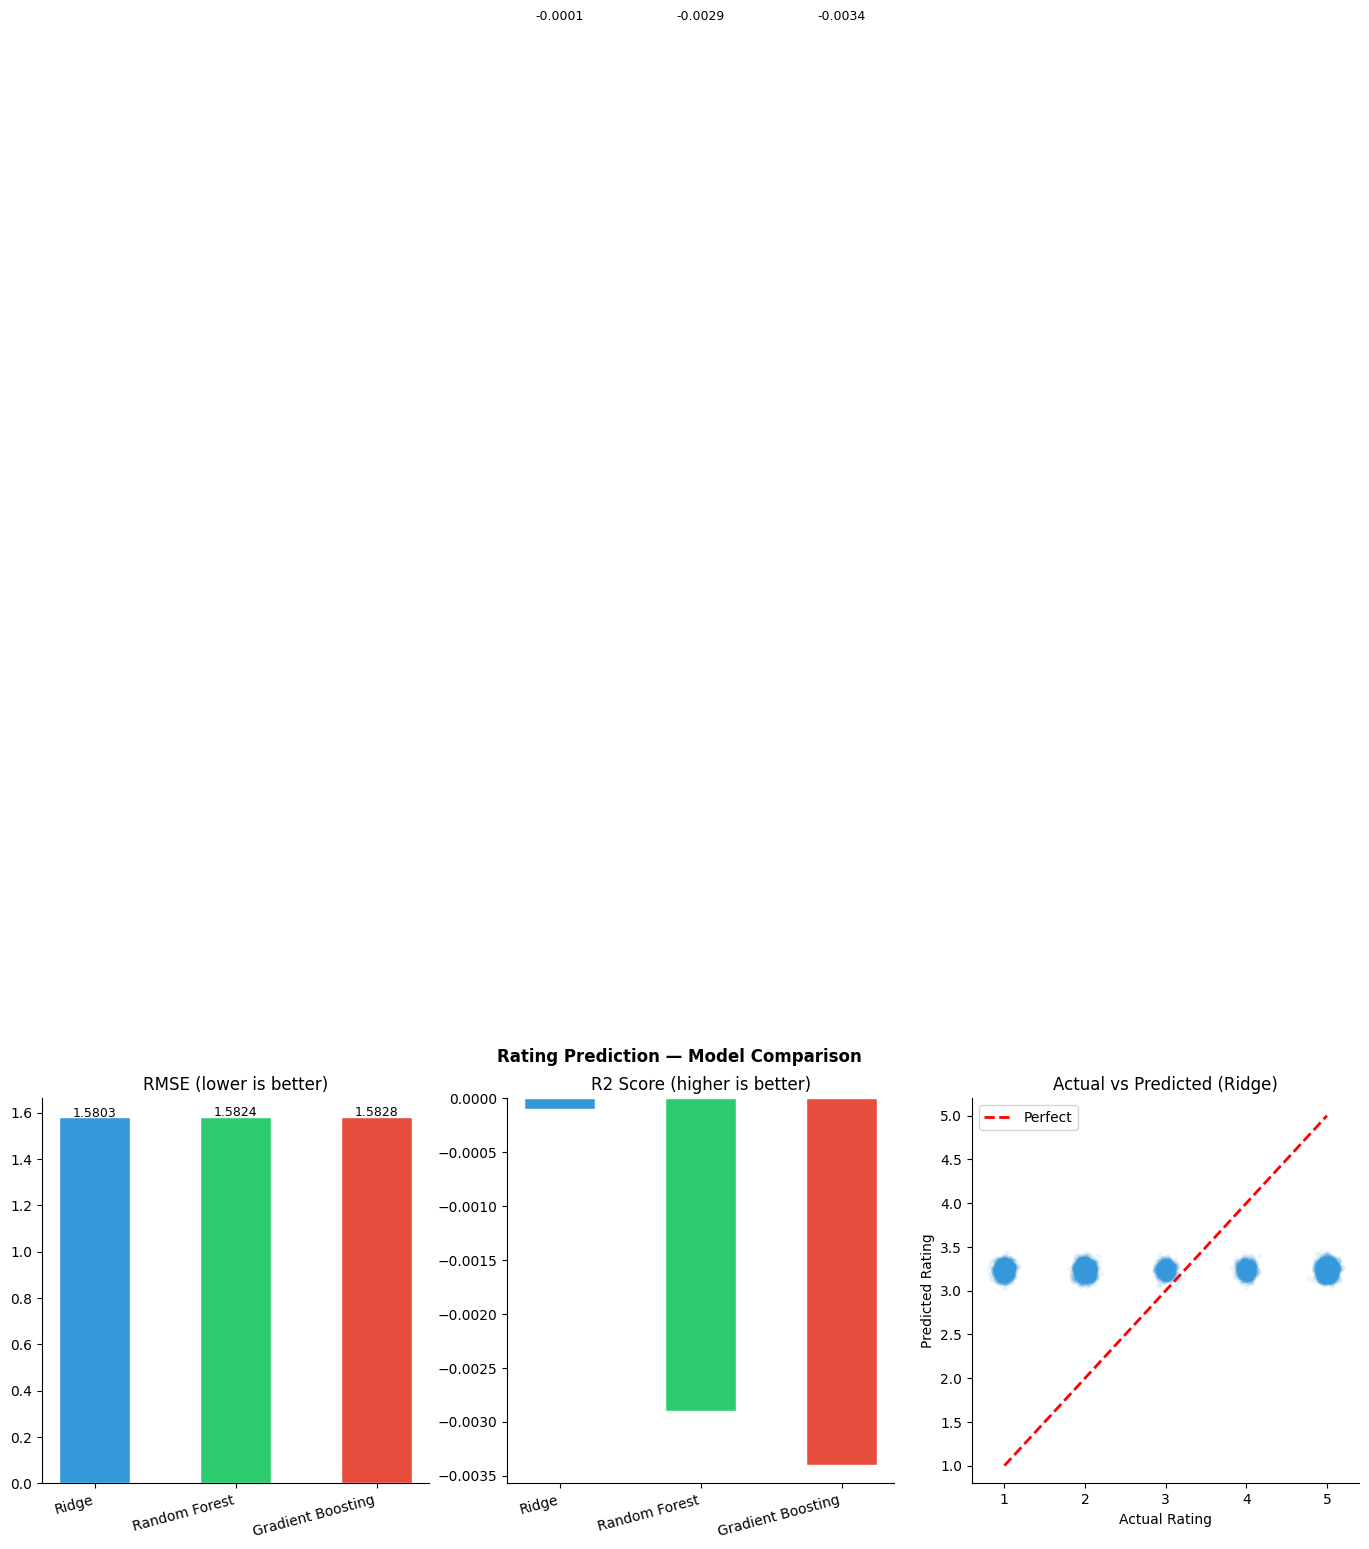

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Rating Prediction — Model Comparison', fontweight='bold')

mc = ['#3498DB','#2ECC71','#E74C3C']

axes[0].bar(results.index, results['RMSE'], color=mc, edgecolor='white', width=0.5)
axes[0].set_title('RMSE (lower is better)')
axes[0].set_xticklabels(results.index, rotation=15, ha='right')
for i, v in enumerate(results['RMSE']): axes[0].text(i, v+0.002, str(round(v,4)), ha='center', fontsize=9)

axes[1].bar(results.index, results['R2'], color=mc, edgecolor='white', width=0.5)
axes[1].set_title('R2 Score (higher is better)')
axes[1].set_xticklabels(results.index, rotation=15, ha='right')
for i, v in enumerate(results['R2']): axes[1].text(i, max(v,0)+0.01, str(round(v,4)), ha='center', fontsize=9)

best_name = results['RMSE'].idxmin()
if best_name == 'Random Forest':  bp = np.clip(rf_pred, 1, 5)
elif best_name == m3_name:         bp = np.clip(m3_pred, 1, 5)
else:                              bp = np.clip(ridge.predict(X_te_s), 1, 5)

jit_a = y_test.values + np.random.normal(0, 0.05, len(y_test))
jit_p = bp               + np.random.normal(0, 0.05, len(bp))
axes[2].scatter(jit_a, jit_p, alpha=0.06, color='#3498DB', s=10)
axes[2].plot([1,5],[1,5],'r--', lw=2, label='Perfect')
axes[2].set_title('Actual vs Predicted (' + best_name + ')')
axes[2].set_xlabel('Actual Rating')
axes[2].set_ylabel('Predicted Rating')
axes[2].legend()

plt.tight_layout()
plt.savefig('../visuals/15_rating_models.png', dpi=150, bbox_inches='tight')
plt.show()


## Feature Importance & Residuals

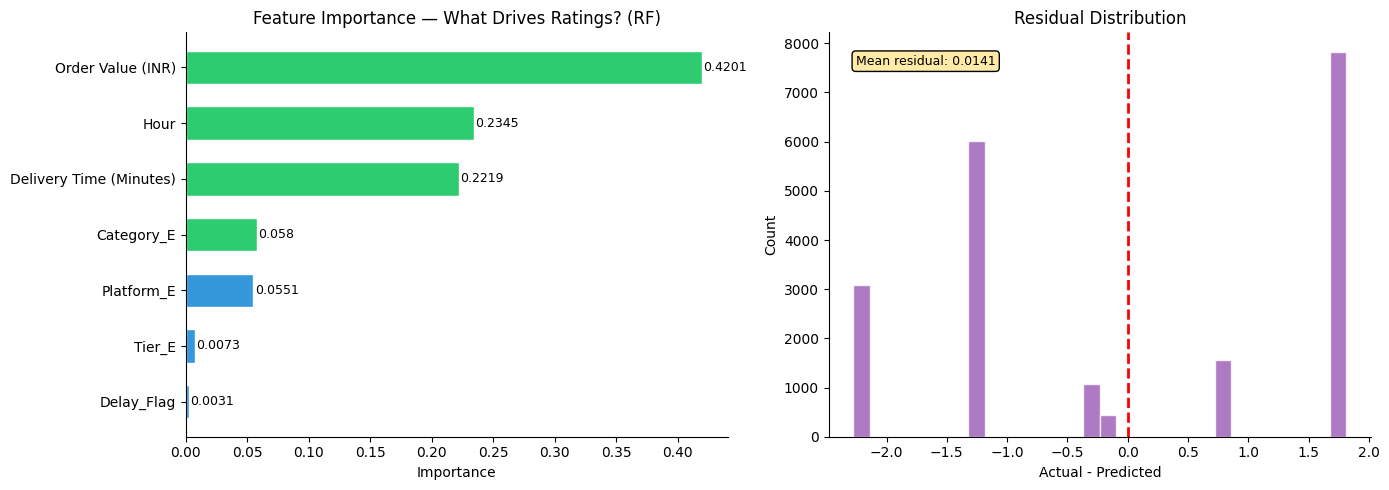

In [5]:
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ECC71' if v >= feat_imp.median() else '#3498DB' for v in feat_imp.values]
axes[0].barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white', height=0.6)
axes[0].set_title('Feature Importance — What Drives Ratings? (RF)')
axes[0].set_xlabel('Importance')
for i, v in enumerate(feat_imp.values):
    axes[0].text(v+0.001, i, str(round(v,4)), va='center', fontsize=9)

residuals = y_test.values - bp
axes[1].hist(residuals, bins=30, color='#9B59B6', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Actual - Predicted')
axes[1].set_ylabel('Count')
axes[1].text(0.05, 0.92, 'Mean residual: '+str(round(residuals.mean(),4)),
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='#FFEAA7'))

plt.tight_layout()
plt.savefig('../visuals/16_rating_importance_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
